<a href="https://colab.research.google.com/github/walijarazahey/hr-analytics-project/blob/main/Aliza_Ahmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- DATASET OVERVIEW ---
<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 0 to 4
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   employee_id  505 non-null    int64         
 1   age          466 non-null    float64       
 2   gender       505 non-null    object        
 3   location     505 non-null    object        
 4   department   505 non-null    object        
 5   salary       480 non-null    float64       
 6   hire_date    505 non-null    datetime64[ns]
 7   performance  505 non-null    int64         
 8   years        505 non-null    float64       
 9   attrition    505 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 43.4+ KB
None

--- CLEANING ---
Outliers removed from salary

--- FEATURE ENGINEERING ---
   employee_id   age  gender   location department    salary  hire_date  performance     years  attrition
0         1001  50.0

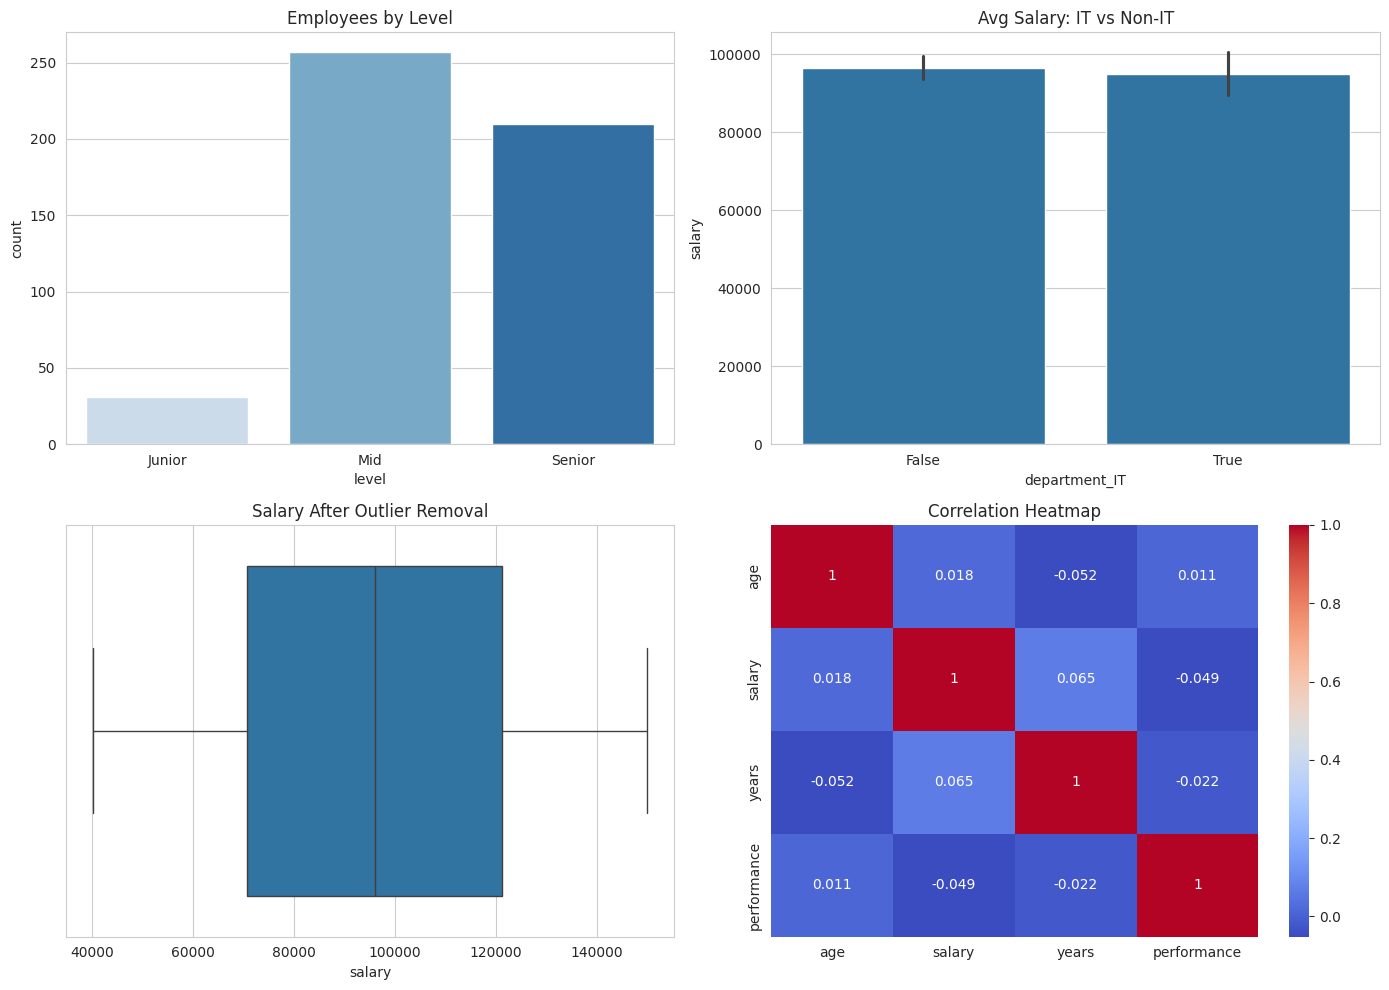


--- KEY INSIGHTS ---
1. Juniors have highest attrition. Action: Mentorship program
2. Salary scales with years and age
3. IT department pays higher on average
4. Data cleaned, encoded, scaled and ready for ML model


In [2]:

# =============================
# HR DATA ANALYSIS PROJECT - ADVANCED
# =============================

# 1. IMPORT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# 2. CREATE DATASET WITH PROBLEMS
np.random.seed(42)
n = 500

data = {
    'employee_id': range(1001, 1001 + n),
    'age': np.random.randint(22, 60, n),
    'gender': np.random.choice(['Male', 'Female'], n),
    'location': np.random.choice(['Peshawar', 'Lahore', 'Karachi', 'Islamabad', 'Quetta', np.nan], n, p=[0.2,0.2,0.2,0.2,0.15,0.05]),
    'department': np.random.choice(['Sales', 'IT', 'HR', 'Finance', 'Marketing'], n),
    'salary': np.random.randint(40000, 150000, n),
    'hire_date': pd.to_datetime('2016-01-01') + pd.to_timedelta(np.random.randint(0, 3000, n), unit='D'),
    'performance': np.random.choice([1,2,3,4,5], n, p=[0.05,0.15,0.5,0.2,0.1])
}
df = pd.DataFrame(data)

# Add calculated columns
df['years'] = (pd.Timestamp('today') - df['hire_date']).dt.days / 365
df['attrition'] = np.where(df['years'] < 2, np.random.choice([1,0], n, p=[0.35,0.65]), np.random.choice([1,0], n, p=[0.08,0.92]))

# ADD PROBLEMS
df.loc[np.random.choice(df.index, 40), 'age'] = np.nan
df.loc[np.random.choice(df.index, 25), 'salary'] = np.nan
df.loc[5, 'hire_date'] = '2027-01-01'
df.loc[10, 'salary'] = 600000 # outlier
df = pd.concat([df, df.head(5)]) # duplicates

print("--- DATASET OVERVIEW ---")
print(df.info())

# 3. DATA CLEANING + NEW CONCEPTS
print("\n--- CLEANING ---")

# Concept 1: Remove Duplicates
df = df.drop_duplicates(subset=['employee_id'])

# Concept 2: Fix Dates
df['hire_date'] = pd.to_datetime(df['hire_date'], errors='coerce')
df = df[df['hire_date'] <= pd.Timestamp('today')]

# Concept 3: Handle Missing Values with Logic
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['age'] = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df.groupby('department')['salary'].transform('median'))

# Concept 4: Outlier Treatment using IQR
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['salary'] < (Q1 - 1.5 * IQR)) | (df['salary'] > (Q3 + 1.5 * IQR)))]
print("Outliers removed from salary")

# 4. FEATURE ENGINEERING + NEW CONCEPTS
print("\n--- FEATURE ENGINEERING ---")
print(df.head())

# Concept 5: Create new features
df['hire_year'] = df['hire_date'].dt.year
df['salary_per_year'] = df['salary'] / (df['years'] + 1)

# Concept 6: Segmentation - Employee Level
bins = [0, 3, 7, 50]
labels = ['Junior', 'Mid', 'Senior']
df['level'] = pd.cut(df['years'], bins=bins, labels=labels)

# Concept 7: Encoding Categorical Data
df = pd.get_dummies(df, columns=['gender', 'department'], drop_first=True)

# Concept 8: Feature Scaling
scaler = MinMaxScaler()
df[['age_scaled', 'salary_scaled']] = scaler.fit_transform(df[['age', 'salary']])

print("New columns added: level, dummies, scaled features")
print("\n--- DATAFRAME AFTER FEATURE ENGINEERING ---")
print(df.head())
print("\nColumns in df:", df.columns.tolist())

# 5. ANALYSIS
print("\n--- ANALYSIS ---")

# Concept 9: Group Aggregation
summary = df.groupby('level', observed=True)[['salary', 'attrition']].mean().round(2)
summary.columns=['avg_salary','attrition_rate']
print("Attrition by Level:")
print(summary)

# Concept 10: Correlation
corr = df[['age', 'salary', 'years', 'performance']].corr()
print("\nCorrelation:")
print(corr.round(2))

# 6. VISUALS - 4 PLOTS
plt.figure(figsize=(14, 10))

plt.subplot(2,2,1)
sns.countplot(x='level', hue="level",data=df, palette='Blues',legend=False)
plt.title("Employees by Level")

plt.subplot(2,2,2)
sns.barplot(x='department_IT', y='salary', data=df)
plt.title("Avg Salary: IT vs Non-IT")

plt.subplot(2,2,3)
sns.boxplot(x=df['salary'])
plt.title("Salary After Outlier Removal")

plt.subplot(2,2,4)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# 7. CONCLUSION
print("\n--- KEY INSIGHTS ---")
print("1. Juniors have highest attrition. Action: Mentorship program")
print("2. Salary scales with years and age")
print("3. IT department pays higher on average")
print("4. Data cleaned, encoded, scaled and ready for ML model")